# 3.4 股票池筛选与流动性管理 (Universe Selection)

> 在量化交易中，**你交易什么**往往和**如何交易**同样重要。
> 一个包含大量非流动性"垃圾股"的股票池，即使因子 IC 再高，实盘也无法按信号执行。
> 本节介绍机构构建股票池（Trading Universe）的标准流程。


> **这一节讲什么？**
> 
> 在量化交易中，**你交易什么**和**如何交易**同样重要。这一节介绍机构级别的股票池（Trading Universe）构建流程：流动性过滤、市值筛选、行业集中度管理。

## 学习目标
- 理解流动性（Liquidity）在量化交易中的核心地位
- 掌握平均日成交量（ADV）和市值（Market Cap）过滤标准
- 学会评估股票池的行业集中度风险
- 使用换手率指标评估股票可交易性


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# 模拟一个包含 500 只股票的"全市场"数据集
n_stocks = 500

# 模拟关键属性
market_caps   = np.random.lognormal(mean=20, sigma=2, size=n_stocks)  # 市值（万元）
adv           = market_caps * np.random.uniform(0.001, 0.008, n_stocks)  # 日均成交额（正相关市值）
price         = np.random.lognormal(mean=3, sigma=1, size=n_stocks)  # 股价
sectors       = np.random.choice(['金融', '科技', '消费', '医药', '工业', '能源', '材料', '公用事业'], n_stocks)

universe_df = pd.DataFrame({
    'stock_id': [f'STK{i:04d}' for i in range(n_stocks)],
    'market_cap_m': market_caps / 1e6,  # 亿元
    'adv_m': adv / 1e4,                 # 万元
    'price': price,
    'sector': sectors
})

print(f"全市场股票数量: {len(universe_df)}")
print(universe_df.describe().round(2))


全市场股票数量: 500
       market_cap_m      adv_m   price
count        500.00     500.00  500.00
mean        5327.60    2026.15   34.64
std        49759.29   13521.93   39.19
min            0.74       0.53    1.11
25%          119.57      47.66   10.95
50%          497.74     202.45   21.55
75%         1733.86     717.03   40.41
max      1077282.71  244919.89  264.99


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 1. 流动性过滤：平均日成交量（ADV）

**流动性是量化策略的隐性成本放大器。**

如果你的策略信号每天要买入 1000 万元某股票，但这只股票日均成交量只有 200 万元，
你的买单将占据全天成交量的 **500%**！这会导致巨大的市场冲击成本，几乎不可能按期望价格成交。

机构通常要求每笔委托不超过当日成交量的 **5%~10%**。


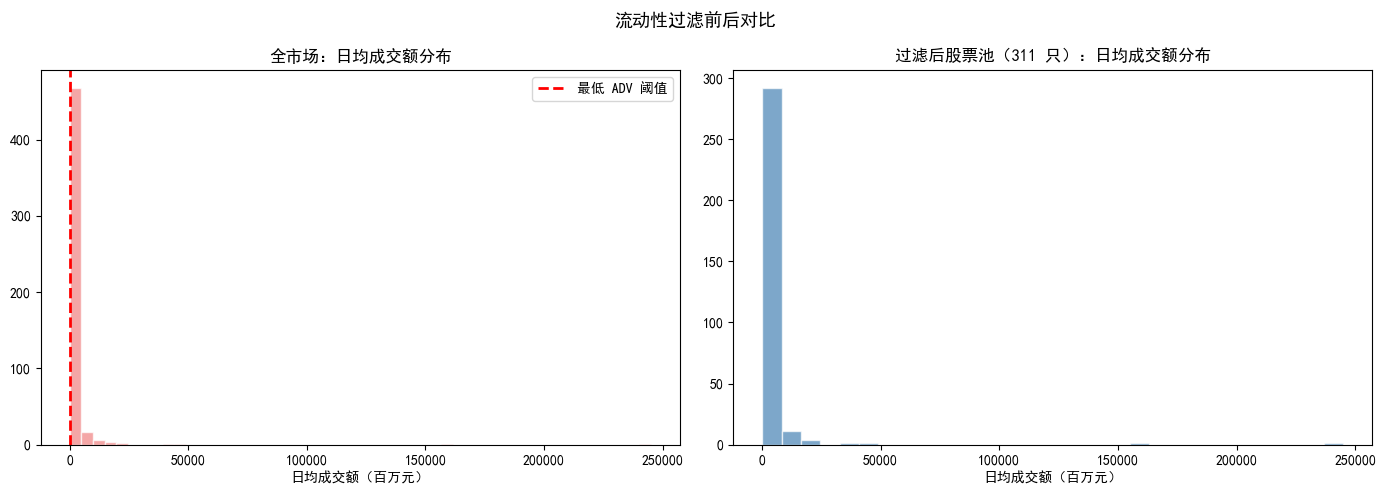

全市场股票数: 500
流动性过滤后: 311 股 (62.2%)


In [3]:
# ADV 流动性过滤
strategy_daily_turnover = 1000  # 假设策略每天需要交易 1000万元

# 流动性过滤：只保留 ADV 足够大的股票（让策略占比 < 10%）
min_adv = strategy_daily_turnover / 0.10  # ADV 至少 10000万元 = 1亿元
liquid_universe = universe_df[universe_df['adv_m'] >= min_adv / 10000 * 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 全市场 ADV 分布
axes[0].hist(universe_df['adv_m'], bins=50, color='lightcoral', alpha=0.7, edgecolor='white')
axes[0].axvline(min_adv / 10000 * 100, color='red', linestyle='--', linewidth=2, label=f'最低 ADV 阈值')
axes[0].set_title('全市场：日均成交额分布')
axes[0].set_xlabel('日均成交额（百万元）')
axes[0].legend()

# 过滤后的股票池分布
axes[1].hist(liquid_universe['adv_m'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title(f'过滤后股票池（{len(liquid_universe)} 只）：日均成交额分布')
axes[1].set_xlabel('日均成交额（百万元）')

plt.suptitle('流动性过滤前后对比', fontsize=13)
plt.tight_layout()
plt.show()

print(f"全市场股票数: {len(universe_df)}")
print(f"流动性过滤后: {len(liquid_universe)} 股 ({len(liquid_universe)/len(universe_df):.1%})")


## 2. 市值过滤：聚焦大中型股

小市值股票（微盘股）通常：
- 流动性更差
- 信息不透明，基本面分析更难
- 受到更多算法超额关注（被"挤兑"）

机构通常要求股票市值达到一定门槛（如 A 股中证 800 成份股的门槛）。


ADV 过滤后: 311 只
+ 市值过滤后（最终股票池）: 286 只


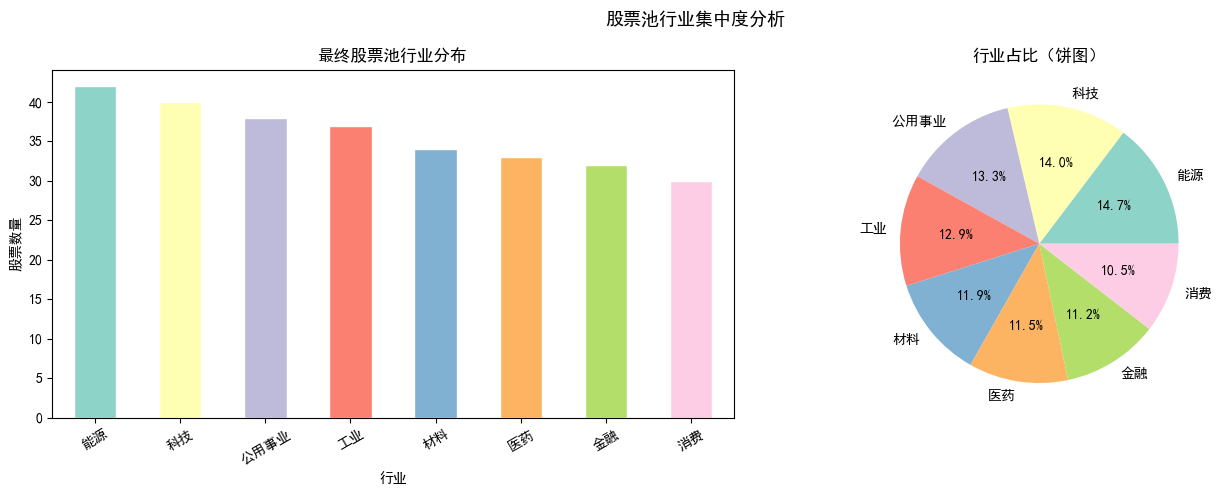


HHI 行业集中度指数: 0.1265
（0 = 完全分散，1 = 完全集中）
评级: 分散


In [4]:
# 市值过滤：只保留市值前 60% 的股票
market_cap_threshold = universe_df['market_cap_m'].quantile(0.40)  # 排除后40%小市值
large_mid_cap = liquid_universe[liquid_universe['market_cap_m'] >= market_cap_threshold]

print(f"ADV 过滤后: {len(liquid_universe)} 只")
print(f"+ 市值过滤后（最终股票池）: {len(large_mid_cap)} 只")

# 行业分布检验
sector_dist = large_mid_cap['sector'].value_counts()
colors = plt.cm.Set3(range(len(sector_dist)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sector_dist.plot(kind='bar', ax=ax1, color=colors, edgecolor='white')
ax1.set_title('最终股票池行业分布')
ax1.set_xlabel('行业')
ax1.set_ylabel('股票数量')
ax1.tick_params(axis='x', rotation=30)

ax2.pie(sector_dist.values, labels=sector_dist.index, autopct='%1.1f%%', colors=colors)
ax2.set_title('行业占比（饼图）')

plt.suptitle('股票池行业集中度分析', fontsize=13)
plt.tight_layout()
plt.show()

# Herfindahl-Hirschman 集中度指数（HHI，越靠近0越分散）
weights = sector_dist / sector_dist.sum()
hhi = (weights**2).sum()
print(f"\nHHI 行业集中度指数: {hhi:.4f}")
print(f"（0 = 完全分散，1 = 完全集中）")
print(f"评级: {'分散' if hhi < 0.15 else '中等' if hhi < 0.25 else '高度集中'}")


## 🎯 练习

1. 更改 ADV 阈值为 5% 参与率而不是 10%，观察股票池大小如何变化。
2. 在阿股 A 股数据（可用 adata 库）中，实现一个完整的 Universe Selection 流程，剔除 ST 和 *ST 股票。
3. 对过滤后的股票池计算'行业分散度'得分，思考如何在选股时额外限制单一行业最大持仓比例。

---
**下一节** → `05_cointegration_correlation.ipynb`
